In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load processed data
master_df = pd.read_csv('../data/processed/master_features.csv')

X = master_df.drop(columns=['DESYNPUF_ID', 'DISENGAGED'])
y = master_df['DISENGAGED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train lighter Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Model trained")

Model trained


In [2]:
import shap

explainer = shap.TreeExplainer(rf)
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP done")
print(type(shap_values))

SHAP done
<class 'numpy.ndarray'>


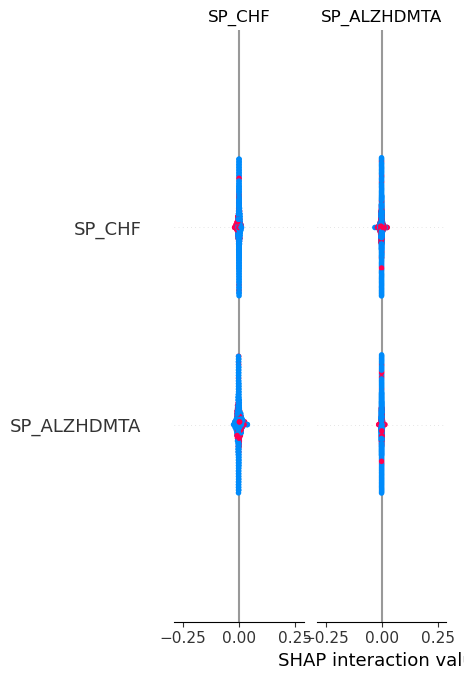

In [3]:
shap.summary_plot(shap_values, X_test_sample, 
                  feature_names=X_test_sample.columns.tolist(),
                  plot_type='bar')

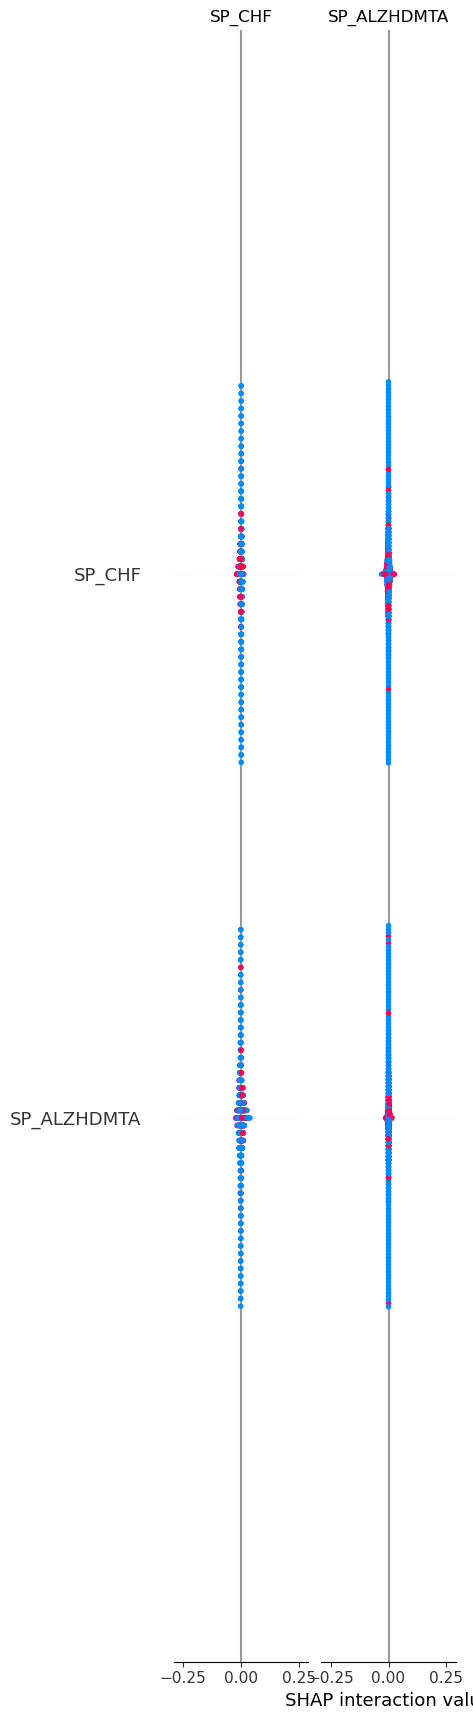

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

# Simple bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X_test_sample, 
                  feature_names=X_test_sample.columns.tolist(),
                  plot_type='bar',
                  max_display=20)
plt.tight_layout()
plt.show()

In [5]:
print(shap_values.shape)
print(X_test_sample.shape)

(500, 46, 2)
(500, 46)


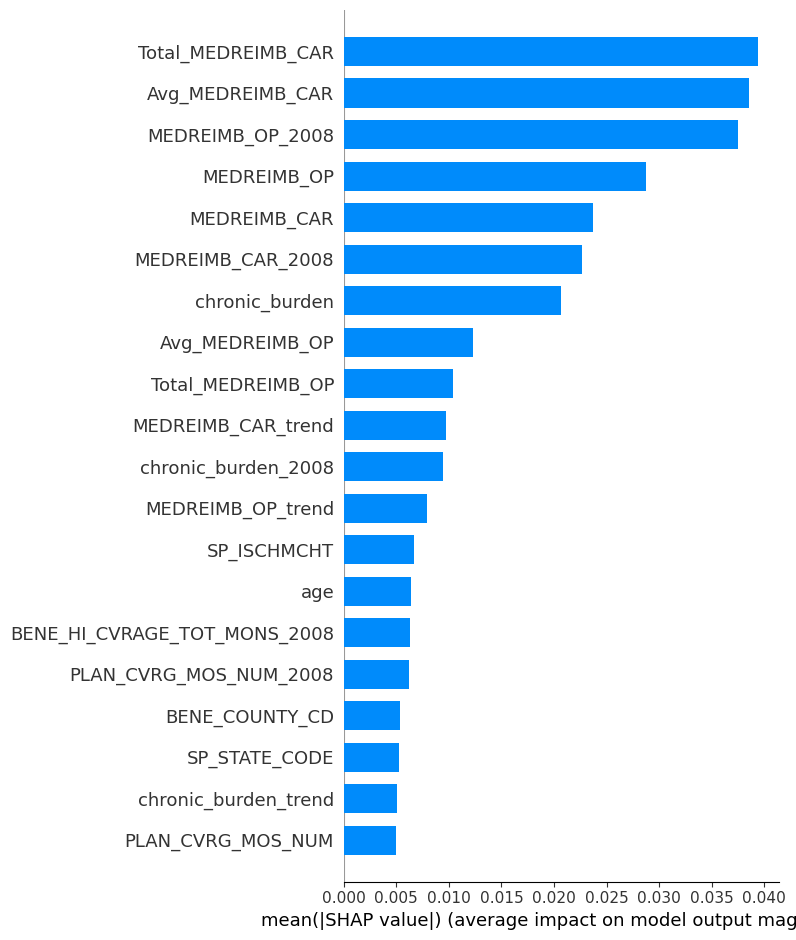

In [6]:
shap.summary_plot(shap_values[:, :, 1], X_test_sample,
                  feature_names=X_test_sample.columns.tolist(),
                  plot_type='bar',
                  max_display=20)
plt.show()

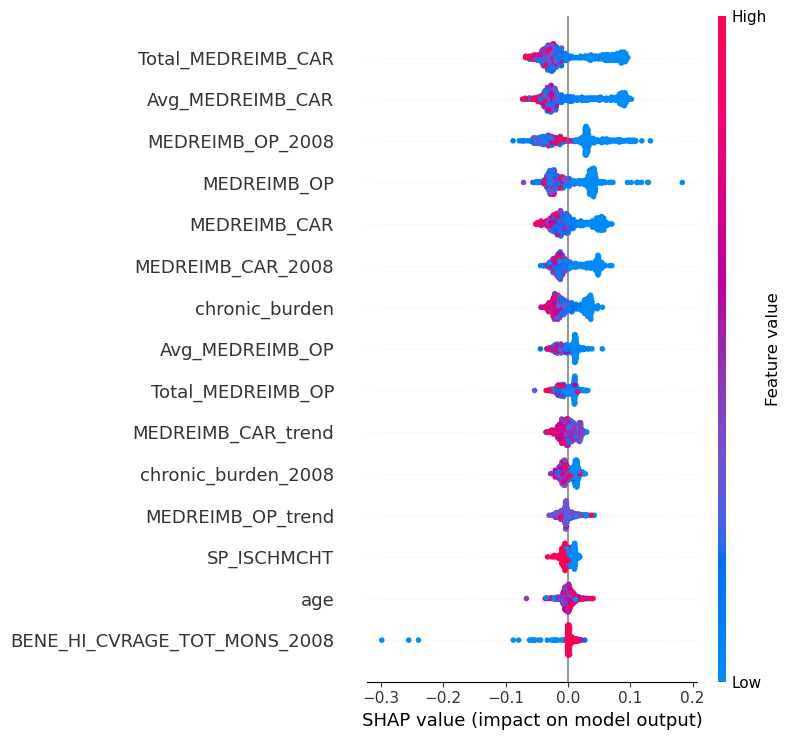

In [7]:
shap.summary_plot(shap_values[:, :, 1], X_test_sample,
                  feature_names=X_test_sample.columns.tolist(),
                  max_display=15)
plt.show()


THE SHAP VALUES TELL US THAT THE MEMBERS WHO HAVE REDUCED FILLING CLAIMS FOR PHYSICIAN VISITS ARE BEING OUSHED TOWARDS DISENGAGEMENT,

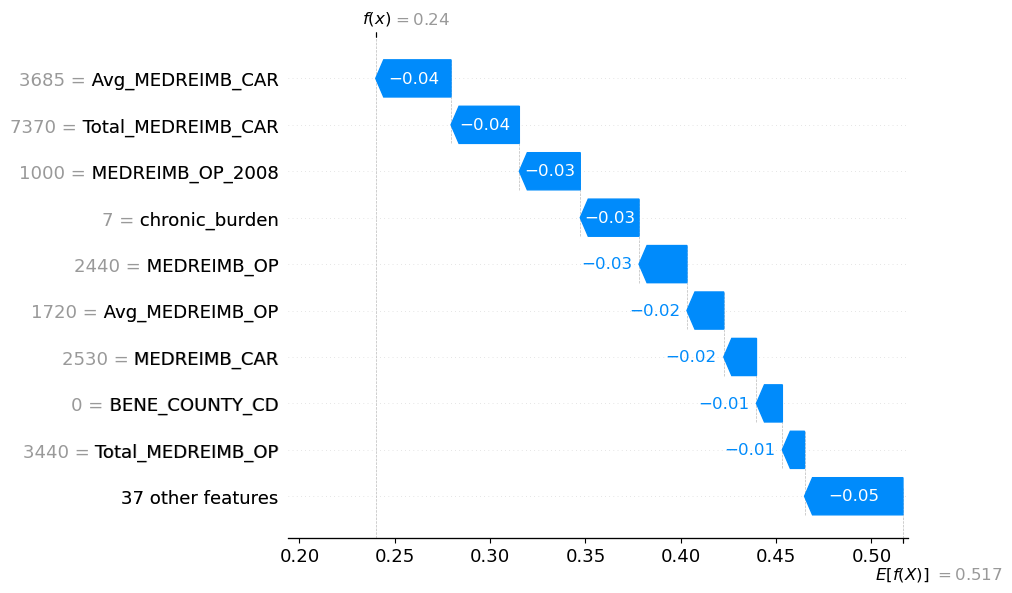

In [8]:
member_idx = 0

# Create explanation object
explanation = shap.Explanation(
    values=shap_values[member_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_sample.iloc[member_idx].values,
    feature_names=X_test_sample.columns.tolist()
)

# Waterfall plot
shap.plots.waterfall(explanation)
plt.show()

INTERPRETTING THIS MEMBER'S RISK SCORE: E[f(x)] = 0.517, is the average disengagement probability of all members. 
f(x) = 0.24, IS THE PROBABILITY RISK SCORE OF THIS MEMBER. THE PLOT TELL US EXACTLY HOW THE MODEL GOT TO THAT POINT.

Starting at 0.517 (average risk), every feature pulled LEFT (toward engaged/lower risk):

Avg_MEDREIMB_CAR = 3685 → -0.04 (high carrier spend = more engaged)
 | Total_MEDREIMB_CAR = 7370 → -0.04 (same story)
 | chronic_burden = 7 → -0.03 (7 conditions but still engaged)
 | MEDREIMB_OP_2008 = 1000 → -0.03 (had outpatient spend in 2008)

In [10]:
y_prob_sample = rf.predict_proba(X_test_sample)[:, 1]

In [12]:
m = y_prob_sample.argmax()
print(f"Highest Risk score member ID: {m}")
print(f"Score: {y_prob_sample[m]: .3f}")

Highest Risk score member ID: 11
Score:  1.000


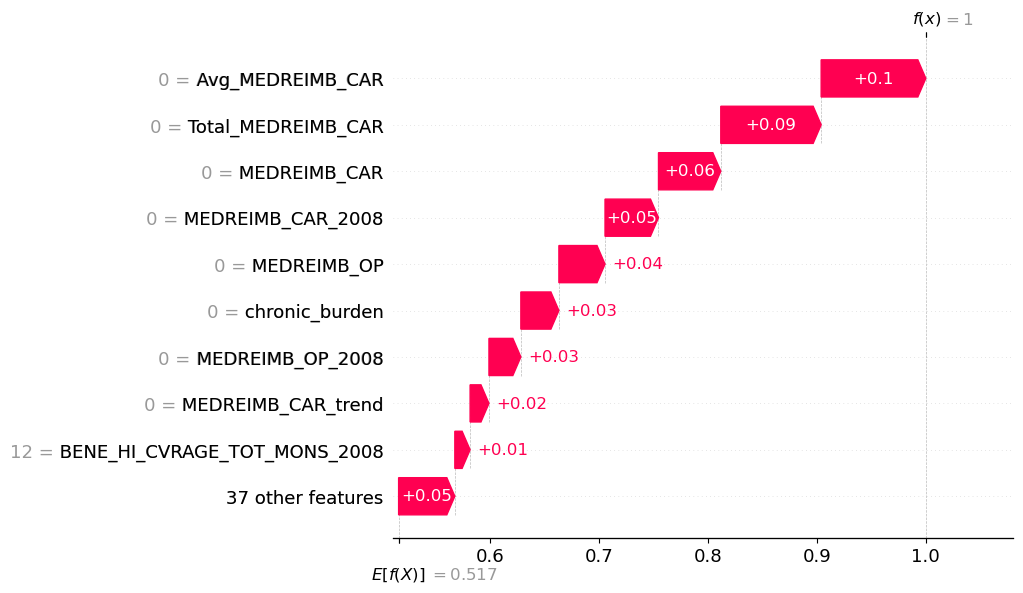

In [14]:
member_idx = y_prob_sample.argmax()  # this gives you index 11

explanation = shap.Explanation(
    values=shap_values[member_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_sample.iloc[member_idx].values,
    feature_names=X_test_sample.columns.tolist()
)

shap.plots.waterfall(explanation)
plt.show()

Every single bar is pushing RIGHT toward disengaged (pink = pushing toward disengaged):

| Avg_MEDREIMB_CAR = 0 → +0.10 (zero carrier spend: never saw a physician)
| Total_MEDREIMB_CAR = 0 → +0.09 (zero total carrier claims)
| MEDREIMB_CAR = 0 → +0.06 (zero 2009 carrier claims)
| chronic_burden = 0 → +0.03 (interesting: zero chronic conditions)
| MEDREIMB_OP = 0 → +0.04 (zero outpatient spend)

In [19]:
# segregating the members into risk buckets: 
x_full = master_df.drop(columns=['DESYNPUF_ID','DISENGAGED'])
master_df['RISK_SCORE']=rf.predict_proba(x_full)[:, 1]

In [21]:
p90=master_df['RISK_SCORE'].quantile(0.90)
p60=master_df['RISK_SCORE'].quantile(0.60)

print(f"90 percentile threshold: {p90}: .3f")
print(f"60 percentile threshold: {p60}: .3f")

90 percentile threshold: 1.0: .3f
60 percentile threshold: 0.74: .3f


In [23]:
master_df['RISK_TIERS']=np.where(
    master_df['RISK_SCORE']>=p90, 'High', 
    np.where(master_df['RISK_SCORE']>=p60, 'Medium', 'Low')
)

print(master_df['RISK_TIERS'].value_counts())

Low       66280
Medium    32497
High      13977
Name: RISK_TIERS, dtype: int64


ACCORDING TO THE 90 PERCENTILE CUT-OFF, THERE ARE AROUND 13977 MEMBERS THAT ARE AT HIGH RISK WITH A SCORE=1.0, WHICH MEANS THE MODEL IS PRETTY SURE ABOUT THESE MEMBERS, WORTH INVESTIGATING FURTHER! BECAUSE HOW CAN A MODEL MAKE SUCH PERFECT PREDICTIONS?

LET'S SAVE THE RISK SEGREGATED MEMEBRS INTO A CSV FOR DOWN STREAM MODELS AND STAKEHOLDERS.

In [27]:
stakeholders_list = master_df[master_df['RISK_TIERS']=='High'][['DESYNPUF_ID', 'RISK_SCORE', 'RISK_TIERS']].sort_values('RISK_SCORE', ascending=False)

print(stakeholders_list.shape)
print(stakeholders_list.head())

stakeholders_list.to_csv('../data/outputs/high_risk_members.csv', index=False)
print(f"Saved to data/outputs/high_risk_members.csv")

(13977, 3)
            DESYNPUF_ID  RISK_SCORE RISK_TIERS
15     0007E57CC13CE880         1.0       High
75634  ABC012EB587767CB         1.0       High
75578  AB9939EB610D1F36         1.0       High
75579  AB9B844FAA3818FC         1.0       High
75580  AB9D9CF5184C8384         1.0       High
Saved to data/outputs/high_risk_members.csv
